In [1]:
import os

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import Dataset, Subset, DataLoader
import torch.optim as optim

from tqdm import tqdm
from VAE import VAE, kl_loss_function, mse_loss_function
from UNet import Unet
from DDPM_2D import Diffusion_Scheme

from PIL import Image

import pandas as pd

In [2]:
path = '/home/alzorrcarri/Documentos/diffusion_models/ldp/skin_lession_images'

df_labels = pd.read_csv(path + '/train-metadata.csv', sep = ',', header = 0)
df_labels = df_labels[['isic_id', 'target']]

In [3]:
image_size = 64
device = 'cuda'
epochs = 30

In [4]:
images = []
labels = []
transform = transforms.Compose([
    transforms.Resize((image_size, image_size)), 
    transforms.ToTensor()])

for n_row in range(df_labels.shape[0]):
    image_name, image_label = df_labels.loc[n_row]
    image_path = path + '/train-image/image/' + image_name + '.jpg'
    if os.path.isfile(image_path):
        image = Image.open(image_path)
        image = transform(image)
        images.append(image)
        labels.append(int(image_label))

0


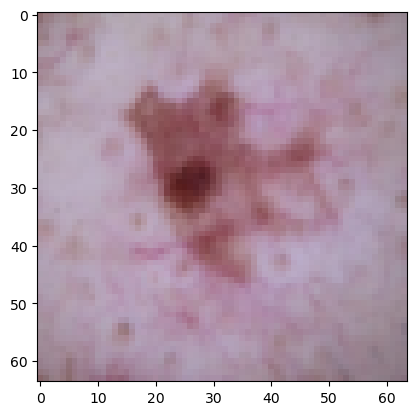

In [5]:
import matplotlib.pyplot as plt

plt.imshow(images[0].permute(1, 2, 0))
print(labels[0])

In [6]:
images[0].shape

torch.Size([3, 64, 64])

In [7]:
len(images), len(labels)

(7496, 7496)

In [8]:
images_tensor = torch.stack(images)
labels_tensor = torch.Tensor(labels)

In [9]:
images_tensor.shape, labels_tensor.shape

(torch.Size([7496, 3, 64, 64]), torch.Size([7496]))

In [10]:
class new_Dataset(Dataset):
    def __init__(self, images, labels):
        self.images = images
        self.labels = labels

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        return self.images[idx], self.labels[idx]

# Crear el dataset con las imágenes de melanoma de piel
dataset = new_Dataset(images_tensor, labels_tensor)

In [11]:
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

In [12]:
def VAE_train(model, dataloader, optimizer, epochs):
    for epoch in range(epochs):
        mse_loss_sum = 0
        kl_loss_sum = 0
        loss_sum = 0
        
        pbar = tqdm(enumerate(dataloader), total=len(dataloader))
        pbar.set_description(f"Epoch {epoch} - Training")
        for i, batch in pbar:
            x, _ = batch
            x = x.to(device)
            mean, log_var = model.encoder(x)
            z_sample = mean + torch.exp(0.5*log_var)*torch.randn(mean.shape).to(device)
            x_bar = model.decoder(z_sample).to(device)

            mse_loss = mse_loss_function(x, x_bar)
            kl_loss = kl_loss_function(mean, log_var)
            loss = torch.mean(mse_loss + kl_loss)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            mse_loss_sum += mse_loss.item()
            kl_loss_sum += kl_loss.item()
            loss_sum += loss.item()
            pbar.set_postfix({'mse_loss' : mse_loss_sum / (i+1), 'kl_loss' : kl_loss_sum / (i+1), 'loss' : loss_sum /(i+1)})

    return model

In [14]:
model = VAE(image_channels=3, down_channels=[32, 64, 128], mid_channels=[128, 128],
            down_sample=[True, True], attn_down=[False, False], norm_channels=32, 
            num_heads=16,num_down_layers=1, num_mid_layers=1, num_up_layers=1, latent_channels=5).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.00001)
model.train()
model = VAE_train(model, dataloader, optimizer, epochs=epochs)

Epoch 29 - Training: 100%|██████████| 235/235 [02:10<00:00,  1.80it/s, mse_loss=2.86e+3, kl_loss=769, loss=3.63e+3]


In [15]:
torch.save(model.state_dict(), 'VAE_skin.pth')

In [16]:
x = images_tensor[0].unsqueeze(0).to(device)
mean, log_var = model.encoder(x)
z_sample = mean + torch.exp(0.5*log_var)*torch.randn(mean.shape).to(device)
x_bar = model.decoder(z_sample)

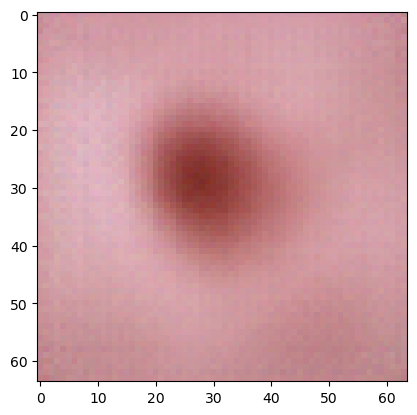

In [17]:
plt.imshow(x_bar[0].permute(1, 2, 0).to('cpu').detach().numpy())

In [18]:
latent_images = []
labels = []

model.eval()
with torch.no_grad():
    for image, label in dataloader:
        image = image.to(device)
        mean, log_var = model.encoder(image)
        latent_images.append(mean)
        labels.append(label)

In [19]:
latent_images = torch.cat(latent_images)
labels = torch.cat(labels)

In [20]:
latent_images.shape, labels.shape

(torch.Size([7496, 5, 16, 16]), torch.Size([7496]))

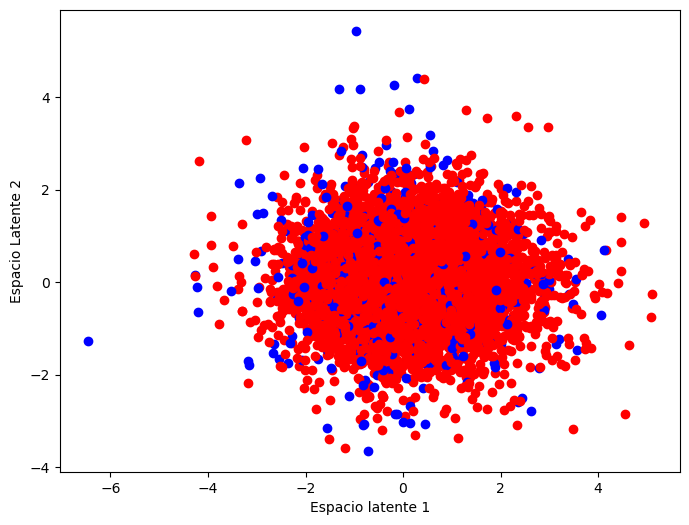

In [31]:
# Crear una figura
plt.figure(figsize=(8, 6))

# Definir una lista de colores para las etiquetas
colors = ['red', 'blue']

# Iterar sobre cada imagen en latent_images
for i in range(latent_images.shape[0]):
    # Obtener las coordenadas (asumimos que son las primeras dos dimensiones)
    coordinates = latent_images[i][0:2].cpu().detach().numpy().tolist()
    
    # Obtener la etiqueta y convertirla a entero
    label = int(labels[i])
    
    # Graficar el punto, eligiendo el color basado en la etiqueta
    plt.scatter(coordinates[0], coordinates[1], color=colors[label])

# Añadir etiquetas a los ejes
plt.xlabel('Espacio latente 1')
plt.ylabel('Espacio Latente 2')

# Mostrar el gráfico
plt.show()


In [21]:
class LatentDataset(Dataset):
    def __init__(self, latents, labels):
        self.latents = latents
        self.labels = labels

    def __len__(self):
        return len(self.latents)

    def __getitem__(self, idx):
        return self.latents[idx], self.labels[idx]

# Crear el dataset con las codificaciones latentes
latent_dataset = LatentDataset(latent_images, labels)

In [26]:
# Filtrar los índices de las muestras que pertenecen a la clase del 1
indices_clase_1 = [i for i, (img, label) in enumerate(latent_dataset) if label == 1.]

# Crear un dataset con solo esos ejemplos (usando Subset)
latent_dataset_clase_1 = Subset(latent_dataset, indices_clase_1)

latent_dataloader = DataLoader(latent_dataset_clase_1, batch_size=10, shuffle=True)

In [34]:
# Filtrar los índices de las muestras que pertenecen a la clase del 1
indices_clase_0 = [i for i, (img, label) in enumerate(latent_dataset) if label == 0.]

# Crear un dataset con solo esos ejemplos (usando Subset)
latent_dataset_clase_0 = Subset(latent_dataset, indices_clase_0)

latent_dataloader = DataLoader(latent_dataset_clase_0, batch_size=32, shuffle=True)

In [35]:
len(latent_dataset_clase_1), len(latent_dataset_clase_0)

(662, 6834)

In [27]:
unet = Unet(image_channels = latent_images.shape[1], down_channels = [128, 256, 256, 256], mid_channels = [256, 256], time_emb_dim = 256,
            down_sample = [False, False, False], num_down_layers = 2, num_mid_layers = 2, num_up_layers = 2, 
            attn_down = [True, True, True], norm_channels = 32, num_heads = 16, conv_out_channels = 128).to(device)
optimizer = optim.AdamW(unet.parameters(), lr=0.00001)
mse = nn.MSELoss()
diffusion = Diffusion_Scheme(image_size = latent_images.shape[2], device = device, timesteps = 1000, beta1 = 0.0015, betaT = 0.0195, beta_scheme = "linear")

for epoch in range(epochs):
    prog_bar = tqdm(latent_dataloader)
    unet.train()
    loss_mean = 0.0
    for count, (images, _) in enumerate(prog_bar):
        images = images.to(device)
        t = diffusion.sample_timesteps(images.shape[0]).to(device)
        x_t, noise = diffusion.noise_images(images, t)
        predicted_noise = unet(x_t, t)
        loss = mse(noise, predicted_noise)
        loss_mean += loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        prog_bar.set_postfix(MSE = loss_mean / (count+1))

OutOfMemoryError: CUDA out of memory. Tried to allocate 2.00 MiB. GPU 0 has a total capacity of 3.94 GiB of which 3.31 MiB is free. Including non-PyTorch memory, this process has 3.93 GiB memory in use. Of the allocated memory 3.85 GiB is allocated by PyTorch, and 17.08 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
torch.save(unet.state_dict(), 'UNet_skin.pth')

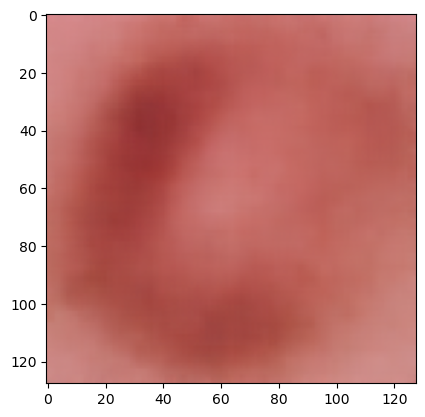

In [101]:
# Generar una imagen en el espacio latente a partir de ruido aleatorio
z = diffusion.sampling(model = unet, num_channels = latent_images.shape[1], n = 10)

import matplotlib.pyplot as plt

model.eval()

x_bar = model.decoder(z)

plt.imshow(x_bar[0].permute(1, 2, 0).cpu().detach().numpy())
